In [1]:
# Блок 1: Импорт библиотек
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 439kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.03MB/s]


Размер тренировочного набора: 54000
Размер валидационного набора: 6000
Размер тестового набора: 10000


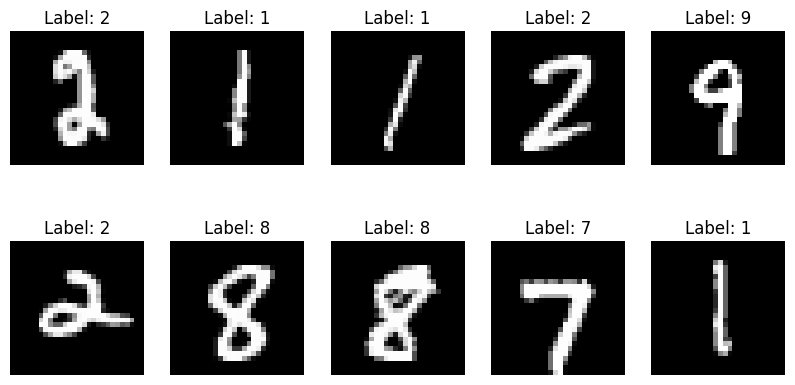

In [2]:
# Блок 2: Подготовка данных
# Параметры
batch_size = 64

# Загрузка и преобразование данных MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Создание DataLoader
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

print(f"Размер тренировочного набора: {len(train_subset)}")
print(f"Размер валидационного набора: {len(val_subset)}")
print(f"Размер тестового набора: {len(test_data)}")

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

In [3]:
# Блок 3: Определение модели трансформера
class TransformerModelWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=3, hidden_dim=128, dropout=0.1, max_seq_len=50):
        super(TransformerModelWithAttention, self).__init__()

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.positional_encoding = nn.Parameter(torch.zeros(1, max_seq_len, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(hidden_dim, num_classes)

        self.attention_weights = []

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        patches = x.unfold(2, 7, 7).unfold(3, 7, 7)
        patches = patches.contiguous().view(batch_size, -1, 7*7)

        x = self.embedding(patches)

        seq_len = patches.size(1)
        x = x + self.positional_encoding[:, :seq_len, :]

        encoder_output = self.transformer_encoder(x)

        self.attention_weights = []
        for layer in self.transformer_encoder.layers:
            _, attn_weights = layer.self_attn(
                encoder_output, encoder_output, encoder_output,
                need_weights=True
            )
            self.attention_weights.append(attn_weights.detach())

        x = encoder_output.mean(dim=1)
        return self.fc_out(x)

model = TransformerModelWithAttention(
    input_dim=7*7,
    num_classes=10,
    num_heads=4,
    num_layers=3,
    hidden_dim=128
).to(device)

print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

TransformerModelWithAttention(
  (embedding): Linear(in_features=49, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
)
Количество параметров: 608906


In [4]:
# Блок 4: Функции обучения и оценки
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total_samples += data.size(0)

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total_samples
    return avg_loss, accuracy

def evaluate(model, device, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total_samples += data.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total_samples
    return avg_loss, accuracy

In [8]:
# Блок 5: Обучение модели
epochs = 10
learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = evaluate(model, device, val_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch}/{epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%\n')

test_loss, test_acc = evaluate(model, device, test_loader, criterion)
print(f'Final Test Accuracy: {test_acc:.2f}%')

Epoch: 1 [0/54000 (0%)]	Loss: 0.211711
Epoch: 1 [6400/54000 (12%)]	Loss: 0.217317
Epoch: 1 [12800/54000 (24%)]	Loss: 0.053918
Epoch: 1 [19200/54000 (36%)]	Loss: 0.046970
Epoch: 1 [25600/54000 (47%)]	Loss: 0.208608
Epoch: 1 [32000/54000 (59%)]	Loss: 0.326817
Epoch: 1 [38400/54000 (71%)]	Loss: 0.082489
Epoch: 1 [44800/54000 (83%)]	Loss: 0.083629
Epoch: 1 [51200/54000 (95%)]	Loss: 0.159951
Epoch 1/10:
Train Loss: 0.1395, Accuracy: 95.66%
Val Loss: 0.1343, Accuracy: 96.02%

Epoch: 2 [0/54000 (0%)]	Loss: 0.063344
Epoch: 2 [6400/54000 (12%)]	Loss: 0.181460
Epoch: 2 [12800/54000 (24%)]	Loss: 0.089460
Epoch: 2 [19200/54000 (36%)]	Loss: 0.064455
Epoch: 2 [25600/54000 (47%)]	Loss: 0.245148
Epoch: 2 [32000/54000 (59%)]	Loss: 0.213675
Epoch: 2 [38400/54000 (71%)]	Loss: 0.076621
Epoch: 2 [44800/54000 (83%)]	Loss: 0.099421
Epoch: 2 [51200/54000 (95%)]	Loss: 0.036209
Epoch 2/10:
Train Loss: 0.1155, Accuracy: 96.31%
Val Loss: 0.0904, Accuracy: 97.38%

Epoch: 3 [0/54000 (0%)]	Loss: 0.070620
Epoch: 3 [6

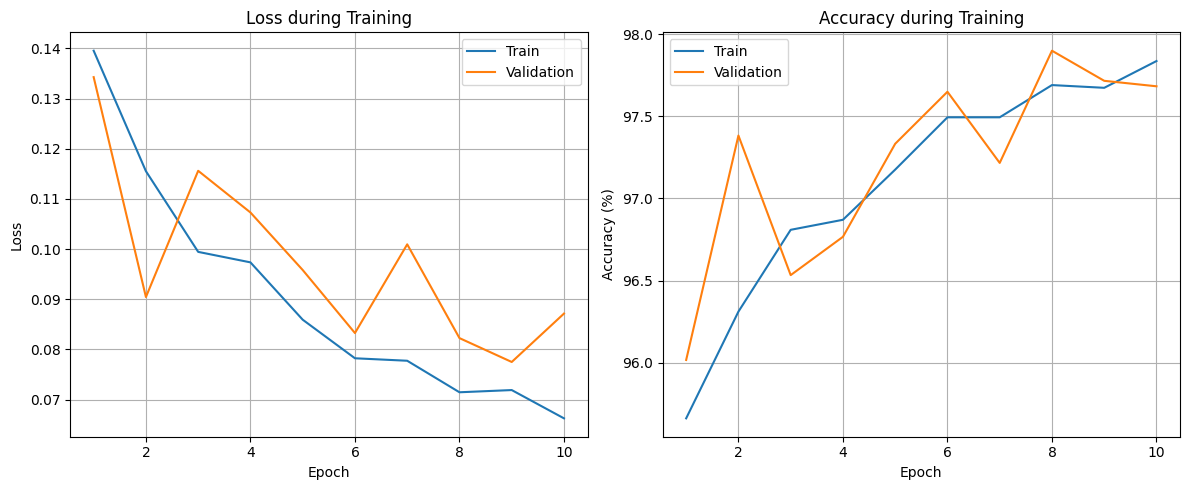

Финальная точность на тестовом наборе: 98.07%


In [9]:
# Блок 6: Визуализация процесса обучения
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train')
plt.plot(range(1, epochs+1), val_losses, label='Validation')
plt.title('Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, label='Train')
plt.plot(range(1, epochs+1), val_accs, label='Validation')
plt.title('Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Вывод финальной точности
print(f"Финальная точность на тестовом наборе: {test_acc:.2f}%")

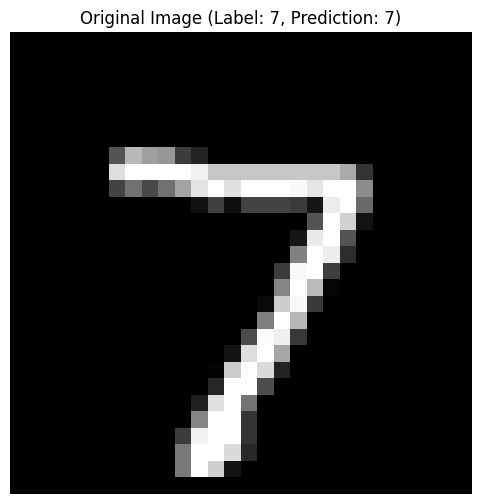

Визуализация внимания для цифры 7 (предсказание: 7)


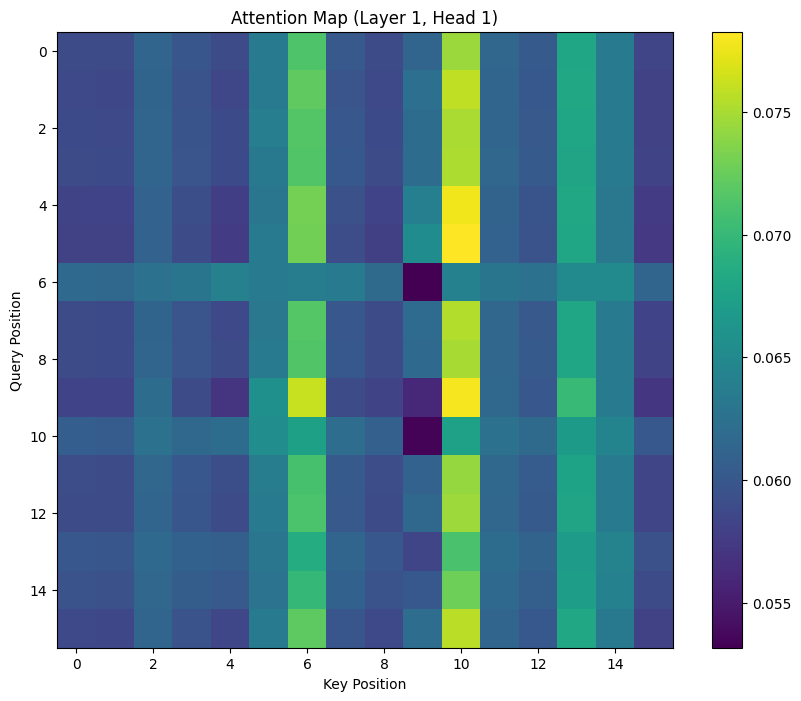

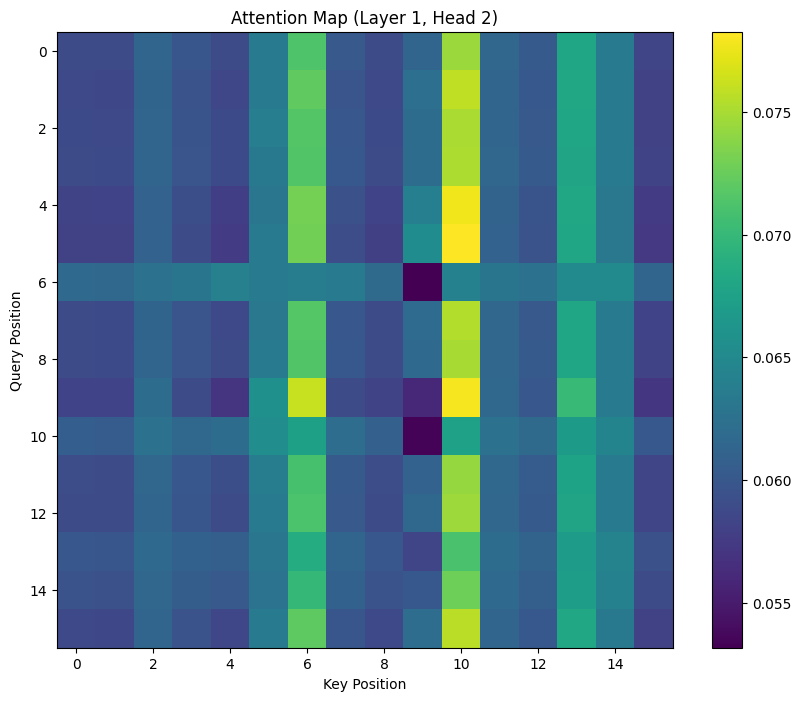

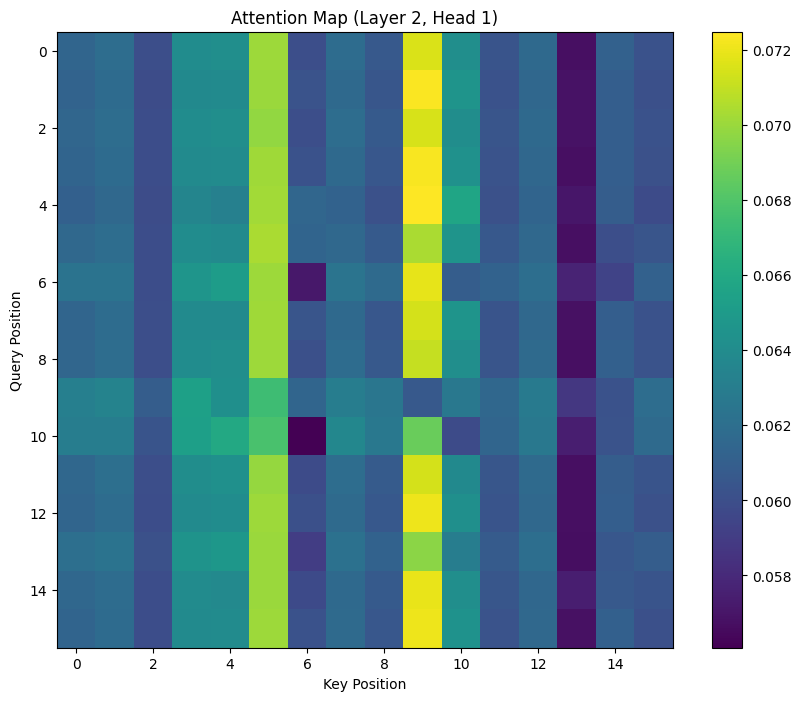

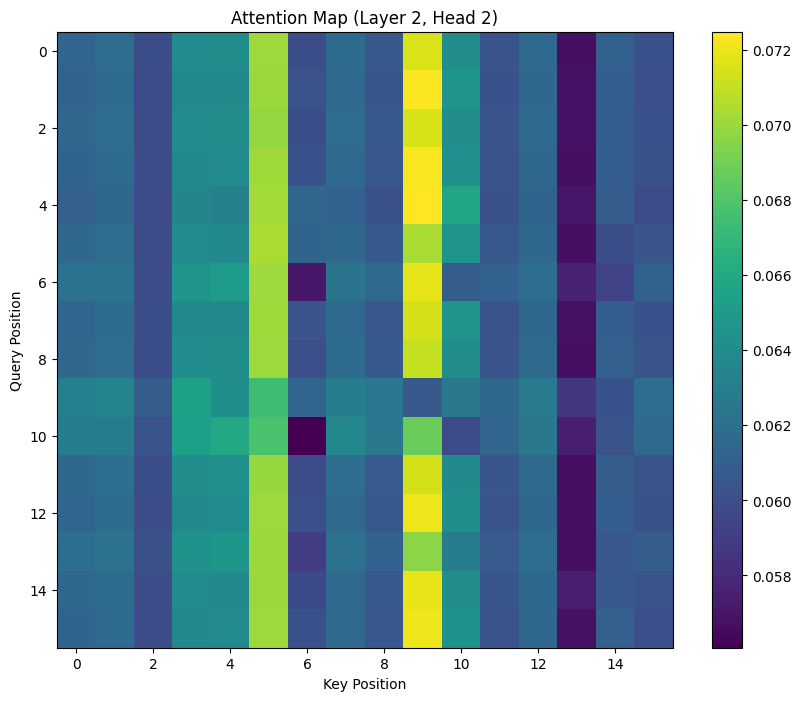

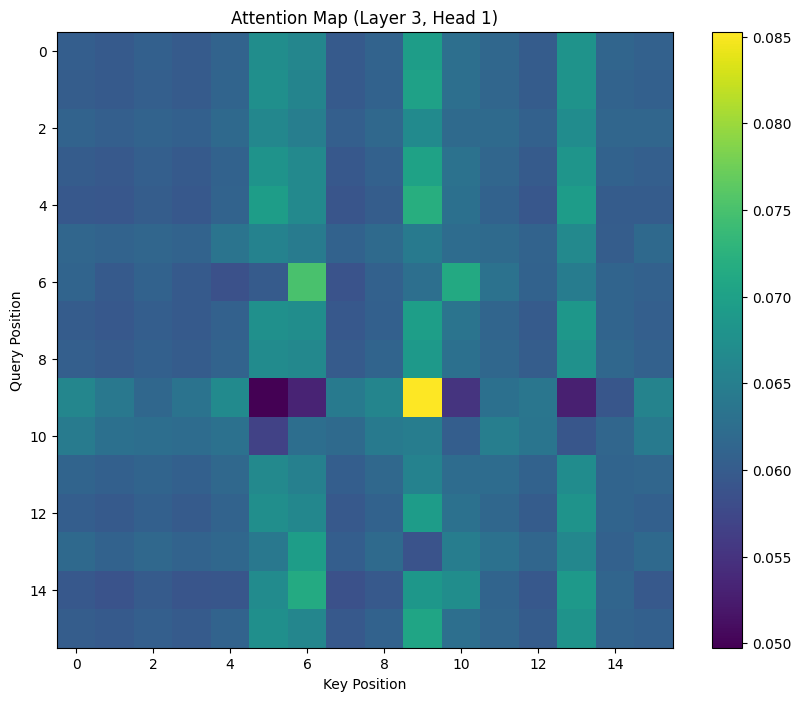

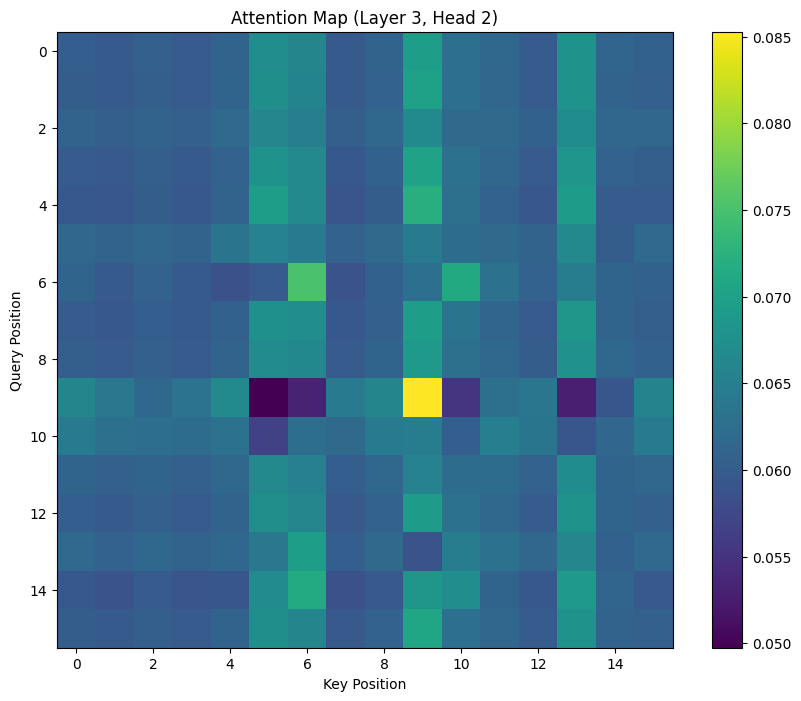

In [12]:
# Блок 7: Визуализация весов внимания
def visualize_attention(model, sample, layer_idx=0, head_idx=0):
    model.eval()
    with torch.no_grad():
        _ = model(sample.unsqueeze(0).to(device))

        # Выбираем конкретный слой
        attn_weights = model.attention_weights[layer_idx]

        if attn_weights.dim() == 4:
            # (batch_size, num_heads, seq_len, seq_len)
            attn_map = attn_weights[0, head_idx].cpu().numpy()
        elif attn_weights.dim() == 3:
            # (batch_size, seq_len, seq_len)
            attn_map = attn_weights[0].cpu().numpy()
        elif attn_weights.dim() == 2:
            # (seq_len, seq_len)
            attn_map = attn_weights.cpu().numpy()

    # Визуализация
    plt.figure(figsize=(10, 8))
    plt.imshow(attn_map, cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(f'Attention Map (Layer {layer_idx+1}, Head {head_idx+1})')
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    plt.show()


def visualize_example_with_attention(model, test_loader):
    model.eval()
    data, target = next(iter(test_loader))
    sample, label = data[0], target[0]

    with torch.no_grad():
        output = model(sample.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()

    # Отображаем исходное изображение
    plt.figure(figsize=(6, 6))
    plt.imshow(sample.squeeze().numpy(), cmap='gray')
    plt.title(f'Original Image (Label: {label}, Prediction: {pred})')
    plt.axis('off')
    plt.show()

    # Визуализируем веса внимания
    num_layers = len(model.attention_weights)
    num_heads = model.transformer_encoder.layers[0].self_attn.num_heads

    print(f"Визуализация внимания для цифры {label} (предсказание: {pred})")

    for layer in range(num_layers):
        for head in range(min(2, num_heads)):
            try:
                visualize_attention(model, sample, layer, head)
            except Exception as e:
                print(f"Ошибка при визуализации слоя {layer}, головы {head}: {str(e)}")
                continue

visualize_example_with_attention(model, test_loader)

**Интерпретация весов**

Вертикальные полосы на 1-ом и 2-ом слое указывают, что модель обнаруживает важность вертикальных элементов цифры 7

Также можно видеть, как выделяются горизонтальные линии (но не так сильно, как вертикальные), видимо модель реагирует на горизонтальную линию цифры 7

На 3ем слое присутствуют яркие точки в центре матрицы. Видимо, так патчи устанавливают связи с областями, в нашем случае -- соединение вертикальной и горизонтальной линии

**Как модель воспринимает данные и принимает решения**
   - Слой 1: Локальные особенности (углы, края, простые текстуры)
   - Слой 2: Группировка локальных признаков (фрагменты цифр)
   - Слой 3: Глобальный "этап" (полное распознавание цифры)

   То есть модель декомпозирует изображение на значимые части, далее собирает информацию и принимает решение на основе ключевых визуальных признаков